<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | Modeling</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning II</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


    


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Table of Contents</h3>
<div style="font-family: Arial, sans-serif; line-height: 1.8; margin-bottom: 30px; padding-left: 10px;">
    <ol style="margin-top: 0; padding-left: 20px;">
        <li><a href="#library-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Library Imports</a></li>
        <li><a href="#data-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Imports</a></li>
        <li>
            <a href="#data-cleaning" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Cleaning</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#duplicates" style="color: #25a890; text-decoration: none;">Missing Values</a></li>
                <li><a href="#variable-consistency" style="color: #25a890; text-decoration: none;">Transformation of Variables</a></li>
            </ul>
        </li>
        <li><a href="#correlation-between-variables" style="color: #25a890; text-decoration: none; font-weight: 500;">Correlation between variables</a></li>
    </ol>
</div>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Install</h2>

In [2]:
!pip install hdbscan minisom umap-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached minisom-2.3.6.tar.gz (13 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached tqdm-4.68.1-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 1.5 MB/s eta 0:00:01
   --------------- ------------------------ 0.8/2.0 MB 1.3 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import hdbscan
from minisom import MiniSom
import umap

import warnings
warnings.filterwarnings('ignore')

c:\Users\simao\anaconda3\envs\Machine_Learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [4]:
X_pca = pd.read_csv('X_pca.csv', index_col='customer_id')

<p style="color: #25a890; font-size: 0.9em;">To widen the views </p>

In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

<p style="color: #25a890; font-size: 0.9em;">To remove outliers that malfunction the code</p>

In [6]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
outlier_mask = iso.fit_predict(X_pca) == 1
X_pca_clean = X_pca[outlier_mask]

print(f"Removed {(~outlier_mask).sum()} outliers, keeping {outlier_mask.sum()} customers")

Removed 331 outliers, keeping 32707 customers


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Elbow Method and Silhouette</h2>

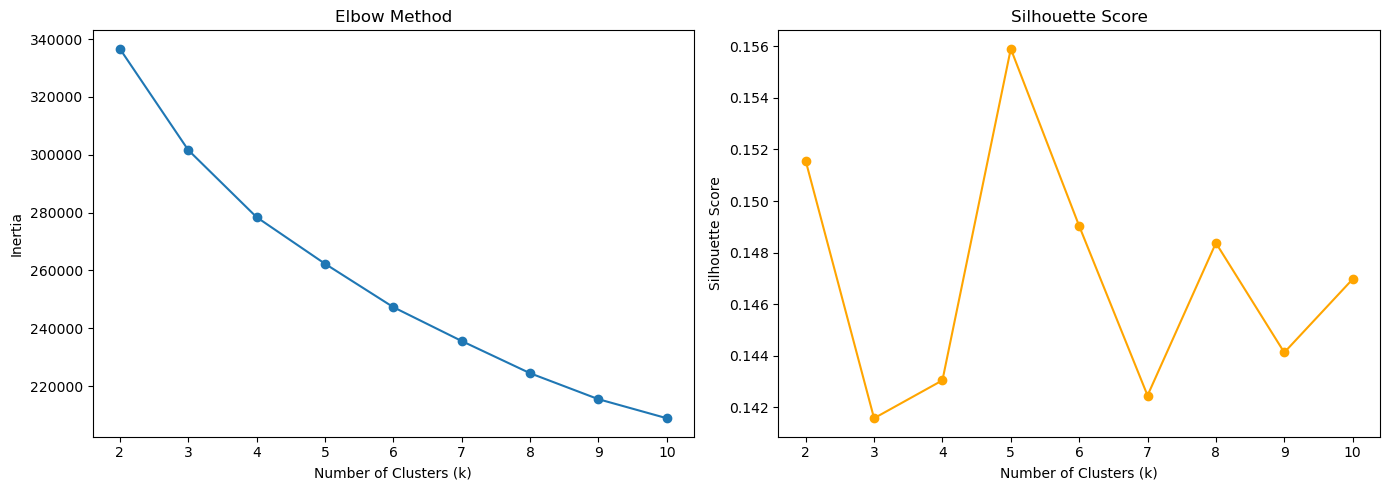

In [8]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_clean)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_clean, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Models</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> K-means</h3>

In [9]:
# ── K-Means ────────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca_clean)
kmeans_score = silhouette_score(X_pca_clean, kmeans_labels)
print(f"K-Means silhouette={kmeans_score:.3f}, clusters={len(set(kmeans_labels))}")

K-Means silhouette=0.156, clusters=5


In [ ]:
X_pca_outliers = pca.transform(X_pca[~outlier_mask])
outlier_labels = kmeans.predict(X_pca_outliers)

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> K-Medoids</h3>

In [ ]:
# ── K-Medoids ──────────────────────────────────────────────────────────────
#kmedoids = KMedoids(n_clusters=4, random_state=42)
#kmedoids_labels = kmedoids.fit_predict(X_pca_clean)
#kmedoids_score = silhouette_score(X_pca_clean, kmedoids_labels)
#print(f"K-Medoids silhouette={kmedoids_score:.3f}, clusters={len(set(kmedoids_labels))}")

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Hierchical Clustering</h3>

In [10]:
# ── Agglomerative with different linkages ──────────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']

for linkage_method in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage_method)
    agg_labels = agg.fit_predict(X_pca_clean)
    score = silhouette_score(X_pca_clean, agg_labels)
    print(f"Agglomerative ({linkage_method:<10})  silhouette={score:.3f}")

Agglomerative (ward      )  silhouette=0.109
Agglomerative (complete  )  silhouette=0.248
Agglomerative (average   )  silhouette=0.336
Agglomerative (single    )  silhouette=0.647


In [ ]:
# ── Dendrogram to visualize structure ──────────────────────────────────────
#linked = linkage(X_pca, method='ward') # Can be 'ward', 'complete', 'average', 'single'

#plt.figure(figsize=(12, 5))
#dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
#plt.title('Dendrogram (Ward Linkage)')
#plt.xlabel('Sample index')
#plt.ylabel('Distance')
#plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> DBSCAN</h3>

In [11]:
# ── DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca_clean)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_pca_clean, dbscan_labels)
    print(f"DBSCAN         silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"DBSCAN         clusters={n_clusters}  noise={n_noise}  (tune eps/min_samples)")

DBSCAN         silhouette=-0.248  clusters=37  noise=32356


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> HDBSCAN</h3>

In [12]:
# ── HDBSCAN ────────────────────────────────────────────────────────────────
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb_labels = hdb.fit_predict(X_pca_clean)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_pca_clean, hdb_labels)
    print(f"HDBSCAN        silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"HDBSCAN        clusters={n_clusters}  noise={n_noise}  (tune min_cluster_size)")

HDBSCAN        silhouette=-0.069  clusters=7  noise=14523


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Self Organizing Map</h3>

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 2.0115412499690324
SOM + KMeans   silhouette=0.102  clusters=4


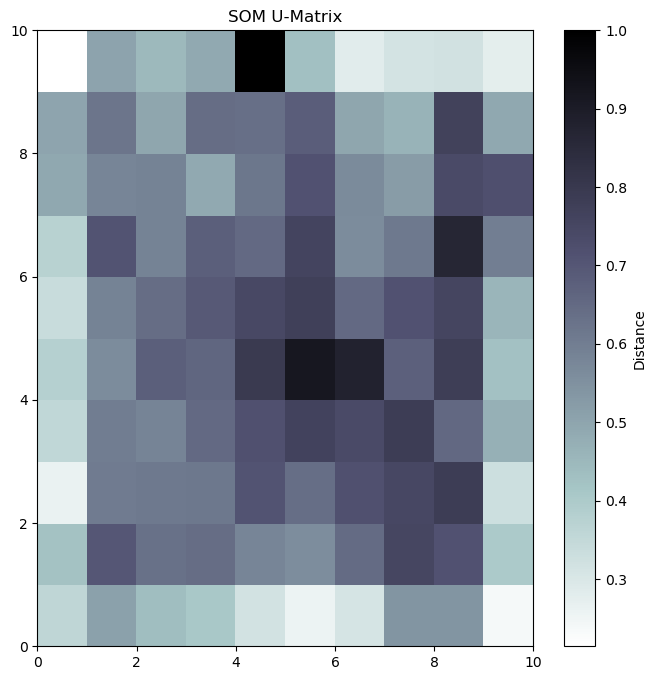

In [13]:
# ── Train SOM ──────────────────────────────────────────────────────────────
som_x, som_y = 10, 10
som = MiniSom(
    x=som_x, y=som_y,
    input_len=X_pca_clean.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=42
)

X_pca_array = X_pca_clean.values  # convert to numpy

som.random_weights_init(X_pca_array)
som.train(X_pca_array, num_iteration=10000, verbose=True)

# ── Assign each customer to a neuron ───────────────────────────────────────
winner_coordinates = np.array([som.winner(x) for x in X_pca_array])

# ── Map neurons to k=4 clusters using K-Means on neuron weights ────────────
weights = som.get_weights().reshape(-1, X_pca_array.shape[1])
kmeans_som = KMeans(n_clusters=4, random_state=42, n_init=10)
neuron_labels = kmeans_som.fit_predict(weights)

som_labels = np.array([neuron_labels[x * som_y + y] for x, y in winner_coordinates])

score = silhouette_score(X_pca_array, som_labels)
print(f"SOM + KMeans   silhouette={score:.3f}  clusters={len(set(som_labels))}")

# ── U-Matrix visualization ─────────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Distance')
plt.title('SOM U-Matrix')
plt.show()


<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Visualization</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> T-SNE</h3>

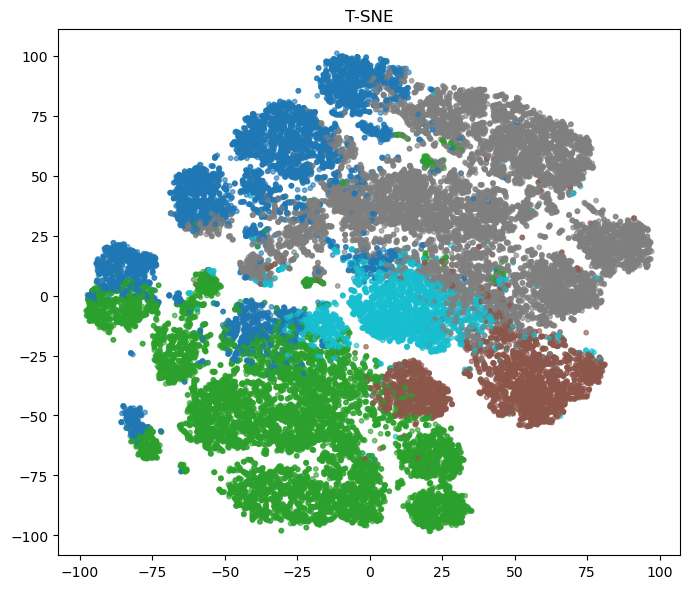

In [14]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_pca_clean)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
ax.set_title('T-SNE')
plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> UMAP</h3>

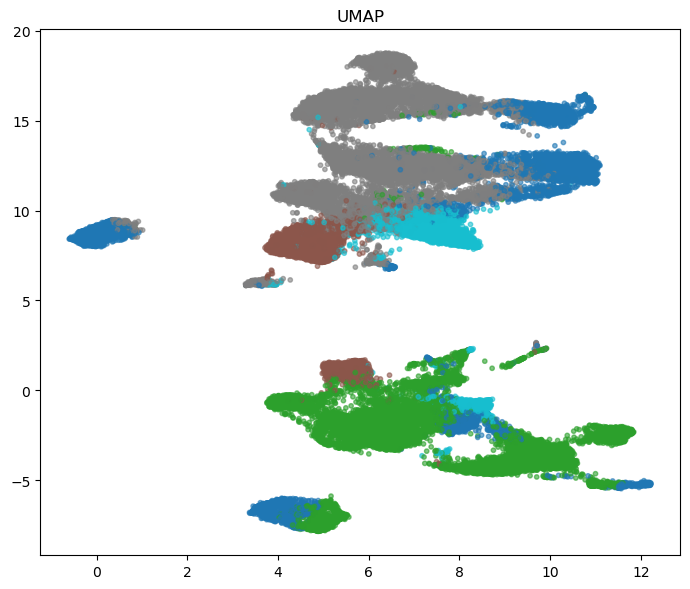

In [15]:
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_pca_clean)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
ax.set_title('UMAP')
plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> PCA</h3>

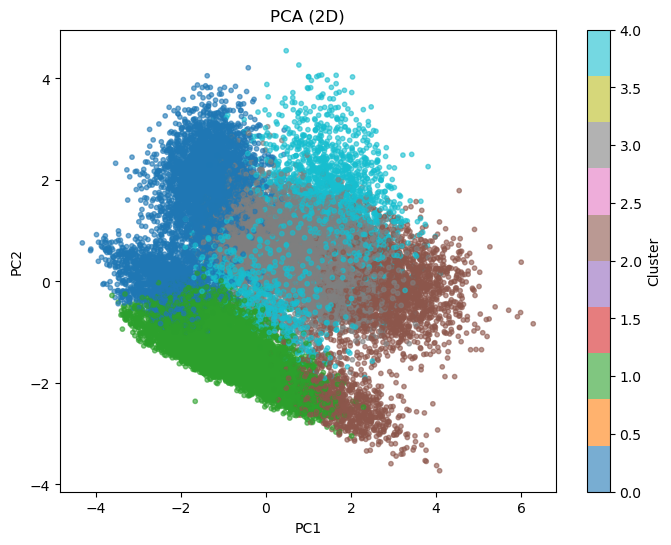

In [16]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_pca_clean)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
plt.title('PCA (2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()